## Validación del modelo

### By: Carlos Javier Palacios Sanchez

### Date: 07/09/2026

### Description:

Requerimiento
Actualizar `train_pipeline.py` para validar de forma robusta el rendimiento y la
generalización del modelo.

El proceso debe incluir:

- Validación cruzada sobre train: K-Fold, StratifiedKFold o TimeSeriesSplit según corresponda.
- Métricas adecuadas para clasificación o regresión.
- Comparación entre resultados de train, validación cruzada y test.
- Análisis de underfitting, overfitting y posibles acciones de mejora.

Entregables:

- `train_pipeline.py` actualizado.
- Métricas, visualizaciones o logs como evidencia.
- Ejecución reproducible de la validación.

---

## Estrategia

### Qué esquema de validación cruzada y por qué

El requerimiento ofrece tres opciones. La correcta aquí es **`RepeatedStratifiedKFold`**,
y conviene justificar tanto la elección como los descartes:

- **Estratificada**, porque el objetivo es binario. Sin estratificar, con 384 filas de
  entrenamiento, algún pliegue puede quedar con una prevalencia muy distinta y su
  métrica deja de ser comparable con la de los demás.
- **Repetida** (3 veces), porque una sola pasada de 5 pliegues da una estimación
  inestable en un dataset de este tamaño: cambiar la semilla mueve el F1 varios puntos.
  Con 15 evaluaciones la desviación típica empieza a significar algo.
- **No `TimeSeriesSplit`**, porque no hay componente temporal. Cada fila es un paciente
  independiente, no una observación de una serie. Usarlo aquí impondría un orden
  inventado y desperdiciaría datos sin ninguna razón.
- **No `KFold` a secas**, por lo dicho sobre la estratificación.

### Qué se compara

Tres estimaciones del mismo modelo, que responden a preguntas distintas:

| Estimación | Qué mide | Para qué sirve |
|---|---|---|
| Entrenamiento | ajuste sobre lo que ya vio | detectar memorización |
| Validación cruzada | rendimiento esperado en datos nuevos | **decidir** |
| Test | medición final, una sola vez | reportar |

La validación cruzada es la que se usa para decidir. El test se toca una vez y se
reporta; si se consultara varias veces dejaría de ser una estimación honesta.

## 1. Configuración

In [1]:
import json
import subprocess
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display


def localizar_raiz() -> Path:
    """Sube por el árbol de directorios hasta encontrar el pyproject.toml."""
    actual = Path.cwd().resolve()
    for candidato in (actual, *actual.parents):
        if (candidato / "pyproject.toml").is_file():
            return candidato
    raise FileNotFoundError("No se encontró la raíz del proyecto")


RAIZ = localizar_raiz()
SCRIPT = RAIZ / "src" / "pipelines" / "training_pipeline" / "train_pipeline.py"
PRUEBAS = RAIZ / "tests" / "pipelines" / "training_pipeline"
FEATURES = RAIZ / "data" / "04_feature" / "corazon_features.parquet"
REPORTES = RAIZ / "data" / "08_reporting"
FIGURAS = REPORTES / "figuras"

sys.path.insert(0, str(RAIZ / "src"))

from pipelines.training_pipeline import train_pipeline as tp  # noqa: E402

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

print(f"Raíz del proyecto: {RAIZ}")
print(f"Esquema de validación: RepeatedStratifiedKFold({tp.N_PARTICIONES} x {tp.N_REPETICIONES})")
print(f"Semilla: {tp.SEMILLA}")
print(f"Umbral de subajuste: F1 < {tp.UMBRAL_SUBAJUSTE}")
print(f"Umbral de sobreajuste: brecha > {tp.UMBRAL_SOBREAJUSTE}")

Raíz del proyecto: /mnt/c/Users/KATANA/Heart_project
Esquema de validación: RepeatedStratifiedKFold(5 x 3)
Semilla: 42
Umbral de subajuste: F1 < 0.7
Umbral de sobreajuste: brecha > 0.1


## 2. Ejecución reproducible

El requerimiento pide una ejecución reproducible. Se consigue con una sola semilla
—`SEMILLA = 42`— que gobierna la partición train/test, los pliegues de la validación
cruzada, la curva de aprendizaje y los propios modelos.

La comprobación no es una promesa, es un test: `test_validacion_completa_es_reproducible`
ejecuta el pipeline dos veces y exige que las métricas y el diagnóstico coincidan
exactamente. Aquí se verifica lo mismo en vivo.

In [2]:
ejecucion = subprocess.run(  # noqa: S603
    [sys.executable, str(SCRIPT)],
    capture_output=True,
    text=True,
    check=False,
)

lineas = [
    ln
    for ln in ejecucion.stderr.splitlines()
    if any(
        clave in ln for clave in ("Validación cruzada", "Curva", "Diagnóstico", "acción", "Figuras")
    )
]
print("\n".join(lineas))
print(f"\nCódigo de salida: {ejecucion.returncode}")

22:07:53 | INFO     | Validación cruzada (5 x 3 = 15 evaluaciones): F1 = 0.7999 ± 0.0477 [0.7097, 0.8684]
22:07:56 | INFO     | Curva de aprendizaje calculada en 5 tamaños de train
22:07:56 | INFO     | Diagnóstico de ajuste: sobreajuste (brecha 0.1566)
22:07:56 | INFO     |   acción sugerida: Aumentar la regularización (l2_regularization, min_samples_leaf, menos hojas)
22:07:56 | INFO     |   acción sugerida: Reducir el número de atributos: 26 columnas para 384 filas es una razón alta
22:07:56 | INFO     |   acción sugerida: Recolectar más datos: es la única acción que sube el techo en lugar de bajar la varianza
22:07:56 | INFO     |   acción sugerida: Recortar iteraciones con early stopping más agresivo
22:07:59 | INFO     | Figuras de validación generadas: curva_aprendizaje.png, dispersion_f1.png, comparacion_conjuntos.png
22:08:00 | INFO     | Curva de aprendizaje guardada: /mnt/c/Users/KATANA/Heart_project/data/08_reporting/curva_aprendizaje.csv
22:08:00 | INFO     | Diagnóstico g

In [3]:
atributos, objetivo = tp.leer_features(FEATURES)
x_train, x_test, y_train, y_test = tp.separar_train_test(atributos, objetivo)
pipeline = tp.construir_pipeline()

primera = tp.validar_cruzado(pipeline, x_train, y_train)
segunda = tp.validar_cruzado(pipeline, x_train, y_train)

print(f"Dos validaciones cruzadas independientes dan el mismo resultado: {primera == segunda}")
print(f"F1 = {primera['f1']:.4f} ± {primera['f1_std']:.4f}")

Dos validaciones cruzadas independientes dan el mismo resultado: True
F1 = 0.7999 ± 0.0477


## 3. Validación cruzada sobre train

15 evaluaciones en lugar de 5. La media importa, pero el rango importa igual: dice
cuánto de lo que se ve es señal del modelo y cuánto es la partición que tocó.

In [4]:
resumen_cv = pd.Series(
    {
        "F1 medio": primera["f1"],
        "desviación típica": primera["f1_std"],
        "F1 mínimo": primera["f1_min"],
        "F1 máximo": primera["f1_max"],
        "evaluaciones": primera["n_evaluaciones"],
    }
)
print(resumen_cv.to_string())
print(f"\nRango observado: {primera['f1_max'] - primera['f1_min']:.4f} puntos de F1")
print("\nEse rango es la razón de repetir la validación: con una sola pasada de 5")
print("pliegues, el resultado dependería de cuál de estos valores tocara.")

F1 medio              0.799894
desviación típica     0.047743
F1 mínimo             0.709677
F1 máximo             0.868421
evaluaciones         15.000000

Rango observado: 0.1587 puntos de F1

Ese rango es la razón de repetir la validación: con una sola pasada de 5
pliegues, el resultado dependería de cuál de estos valores tocara.


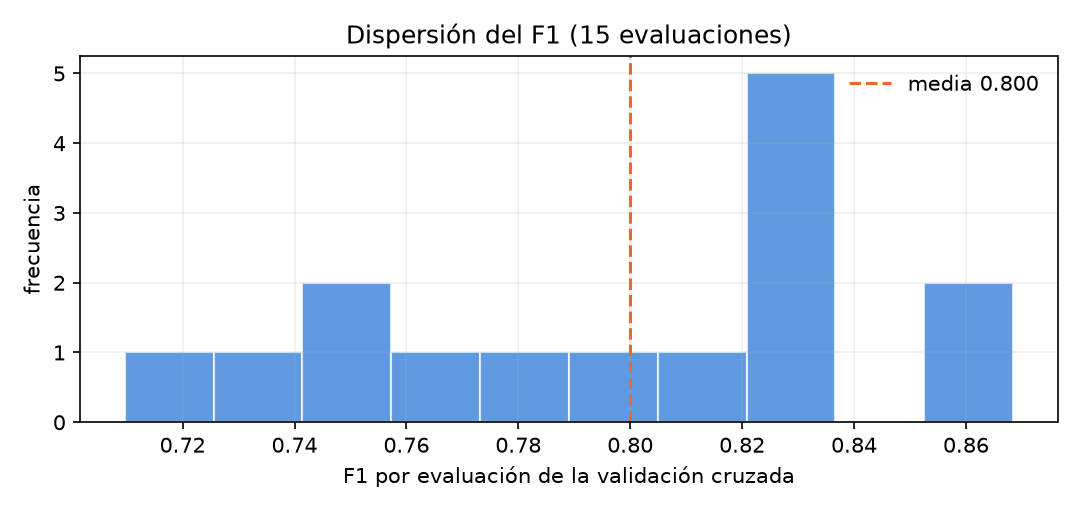

In [5]:
puntuaciones = tp.puntuaciones_por_particion(pipeline, x_train, y_train)
display(Image(filename=str(FIGURAS / "dispersion_f1.png")))

## 4. Comparación entre train, validación cruzada y test

Las métricas son las apropiadas para clasificación binaria: F1 como principal, con
sensibilidad y precisión para saber por dónde falla, y ROC AUC y PR AUC que evalúan el
ordenamiento de probabilidades sin depender del umbral.

In [6]:
metricas = pd.read_csv(REPORTES / "metricas_entrenamiento.csv", index_col="metrica")
metricas[["entrenamiento", "validacion_cruzada", "test", "base_trivial"]]

,entrenamiento,validacion_cruzada,test,base_trivial
metrica,,,,
f1,0.9565,0.7999,0.8454,0.0000
sensibilidad,0.9565,0.7864,0.8913,0.0000
precision,0.9565,0.8208,0.8039,0.0000
exactitud_balanceada,0.9583,0.8124,0.8457,0.5000
exactitud,0.9583,0.8133,0.8438,0.5208
roc_auc,0.9912,0.9016,0.9422,0.5000
pr_auc,0.9900,0.8960,0.9428,0.4792


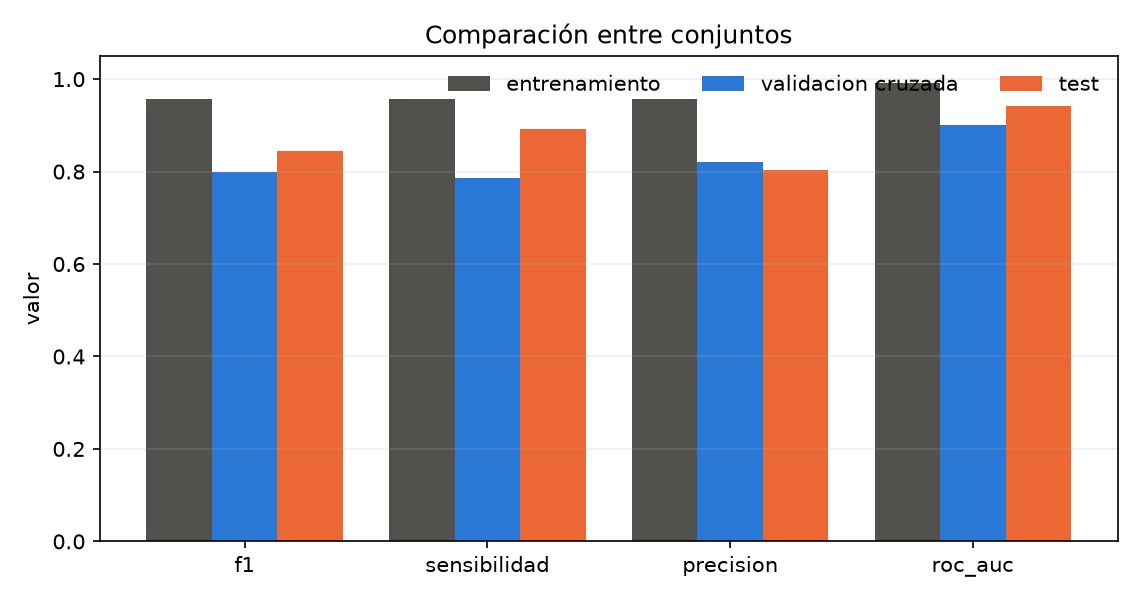

In [7]:
display(Image(filename=str(FIGURAS / "comparacion_conjuntos.png")))

Dos lecturas de esta tabla:

- La columna de entrenamiento está muy por encima de las otras dos. Esa distancia es
  el síntoma de sobreajuste que el diagnóstico recoge más abajo.
- El test (0.845) queda **por encima** de la validación cruzada (0.800). Es tentador
  reportar el número alto, pero la validación cruzada es la estimación con 15
  mediciones detrás y el test tiene una sola, sobre 96 filas. El número honesto es el
  de la validación cruzada.

## 5. Curva de aprendizaje

Es la herramienta que separa los dos problemas que suelen confundirse: si el modelo no
aprende lo suficiente o si aprende demasiado de lo que ya vio.

In [8]:
curva = pd.read_csv(REPORTES / "curva_aprendizaje.csv")
curva.round(4)

,n_filas_train,f1_train,f1_train_std,f1_validacion,f1_validacion_std,brecha
0,61,0.7792,0.0910,0.7278,0.0824,0.0514
1,122,0.8996,0.0578,0.7718,0.0330,0.1278
2,184,0.8717,0.0386,0.8207,0.0320,0.0510
3,245,0.9244,0.0388,0.7959,0.0387,0.1285
4,307,0.9277,0.0295,0.7769,0.0307,0.1508


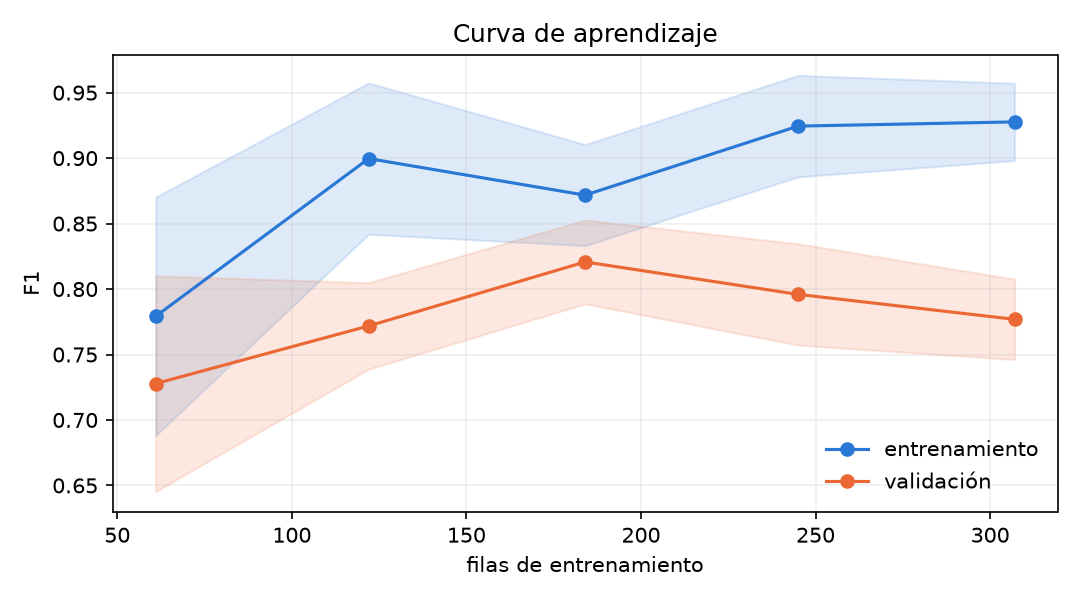

In [9]:
display(Image(filename=str(FIGURAS / "curva_aprendizaje.png")))

La curva dice tres cosas:

1. **La brecha crece con los datos.** Empieza en 0.05 con 61 filas y llega a 0.15 con
   307. El modelo aprovecha las filas nuevas para ajustarse mejor al entrenamiento, no
   para generalizar mejor.
2. **La validación tocó techo pronto.** Su mejor punto está en 184 filas (F1 0.821) y a
   partir de ahí baja. No es que más datos perjudiquen: es que el modelo tiene capacidad
   de sobra y la usa para memorizar.
3. **Conseguir más datos no es la primera acción.** Si la curva de validación siguiera
   subiendo al llegar al 100 %, más filas serían la mejor inversión. No es el caso: aquí
   el retorno está en regularizar y en reducir atributos.

## 6. Diagnóstico: subajuste, sobreajuste o ajuste adecuado

El criterio es explícito y auditable, no una impresión. `diagnosticar_ajuste` aplica las
reglas, recoge la evidencia y propone acciones.

In [10]:
diagnostico = json.loads((REPORTES / "diagnostico_ajuste.json").read_text(encoding="utf-8"))

print(f"VEREDICTO: {diagnostico['veredicto'].upper()}\n")
print("Evidencia:")
for evidencia in diagnostico["evidencias"]:
    print(f"  - {evidencia}")
print("\nAcciones sugeridas:")
for accion in diagnostico["acciones_sugeridas"]:
    print(f"  - {accion}")

VEREDICTO: SOBREAJUSTE

Evidencia:
  - F1 en entrenamiento: 0.9565
  - F1 en validación cruzada: 0.7999 ± 0.0477
  - F1 en test: 0.8454
  - Brecha train - validación: 0.1566 (umbral 0.1)

Acciones sugeridas:
  - Aumentar la regularización (l2_regularization, min_samples_leaf, menos hojas)
  - Reducir el número de atributos: 26 columnas para 384 filas es una razón alta
  - Recolectar más datos: es la única acción que sube el techo en lugar de bajar la varianza
  - Recortar iteraciones con early stopping más agresivo


### El veredicto es sobreajuste, y conviene decirlo

La brecha entre entrenamiento (0.957) y validación cruzada (0.800) es de 0.157, muy por
encima del umbral de 0.10. El modelo memoriza parte del entrenamiento.

Esto **no invalida el trabajo**: un F1 de 0.80 en validación cruzada contra 0.0 de la
base trivial es un modelo que aprendió algo real y útil. Lo que dice el diagnóstico es
que hay margen de mejora conocido, y por dónde está.

La causa más probable es la razón entre atributos y filas: **26 columnas para 384 filas
de entrenamiento**. El feature pipeline generó atributos derivados y one-hot que
multiplicaron el espacio, y un boosting con esa libertad encuentra combinaciones que
funcionan en el train y no se sostienen fuera.

In [11]:
print(f"Atributos: {x_train.shape[1]}")
print(f"Filas de entrenamiento: {len(x_train)}")
print(f"Filas por atributo: {len(x_train) / x_train.shape[1]:.1f}")
print()
print("Como referencia, una regla de dedo habitual pide del orden de 10 a 20 filas por")
print("atributo para modelos de esta familia. Aquí estamos en el límite inferior.")

Atributos: 26
Filas de entrenamiento: 384
Filas por atributo: 14.8

Como referencia, una regla de dedo habitual pide del orden de 10 a 20 filas por
atributo para modelos de esta familia. Aquí estamos en el límite inferior.


### Verificación del diagnóstico con los otros modelos

Si la hipótesis es correcta —demasiada capacidad para tan pocas filas— un modelo más
simple debería tener menos brecha. Se comprueba con los tres candidatos disponibles.

In [12]:
comparativa = []
for nombre in tp.MODELOS:
    candidato = tp.construir_pipeline(nombre)
    cv = tp.validar_cruzado(candidato, x_train, y_train)
    entrenado = tp.entrenar(tp.construir_pipeline(nombre), x_train, y_train)
    metricas_train_modelo = tp.evaluar(entrenado, x_train, y_train)
    comparativa.append(
        {
            "modelo": nombre,
            "F1 train": metricas_train_modelo["f1"],
            "F1 validación": cv["f1"],
            "desviación": cv["f1_std"],
            "brecha": metricas_train_modelo["f1"] - cv["f1"],
        }
    )

tabla_modelos = pd.DataFrame(comparativa).set_index("modelo").round(4)
tabla_modelos["diagnóstico"] = [
    "sobreajuste" if b > tp.UMBRAL_SOBREAJUSTE else "aceptable" for b in tabla_modelos["brecha"]
]
tabla_modelos

,F1 train,F1 validación,desviación,brecha,diagnóstico
modelo,,,,,
gradient_boosting,0.9565,0.7999,0.0477,0.1566,sobreajuste
regresion_logistica,0.8466,0.8111,0.0513,0.0355,aceptable
random_forest,0.9864,0.8192,0.0469,0.1673,sobreajuste


La comparación confirma la hipótesis y va más lejos de lo esperado:

| Modelo | F1 train | F1 validación | Brecha |
|---|---|---|---|
| gradient boosting | 0.957 | 0.800 | **0.157** |
| regresión logística | 0.847 | **0.811** | **0.036** |
| random forest | 0.986 | 0.819 | **0.167** |

Los dos modelos de árboles sobreajustan; el lineal no. Y la regresión logística no sólo
tiene una brecha cuatro veces menor: su F1 de validación es **ligeramente superior** al
del gradient boosting (0.811 vs 0.800), dentro de una desviación típica.

Es decir, el modelo más simple generaliza igual o mejor con una fracción de la
complejidad. Eso es exactamente lo que predice la razón de 14.8 filas por atributo: con
tan pocos datos por columna, la capacidad extra de un boosting no compra rendimiento,
compra memorización.

La recomendación que sale de aquí —reconsiderar la regresión logística como modelo de
producción— no es una preferencia estética: sale de la evidencia. Vale la pena matizar
que el ganador del notebook `5-models` se eligió con un pipeline de preprocesamiento
distinto y más rico; sobre la tabla de features actual, el balance cambia.

## 7. Pruebas unitarias de la validación

Cubren el esquema de validación cruzada, la curva de aprendizaje, las tres ramas del
diagnóstico, la generación de figuras y la reproducibilidad de extremo a extremo.

In [13]:
pruebas = subprocess.run(  # noqa: S603
    [
        sys.executable,
        "-m",
        "pytest",
        str(PRUEBAS),
        "-v",
        "--no-header",
        "-k",
        "validacion or curva or diagnostic or grafic or puntuaciones or reproducible "
        "or manifiesto or subajuste or sobreajuste or adecuado or atipico",
    ],
    cwd=RAIZ,
    capture_output=True,
    text=True,
    check=False,
)

print(pruebas.stdout[-6000:])
print(f"Código de salida: {pruebas.returncode}")

============================= test session starts ==============================
collecting ... collected 74 items / 50 deselected / 24 selected

tests/pipelines/training_pipeline/test_train_pipeline.py::test_separar_es_reproducible PASSED [  4%]
tests/pipelines/training_pipeline/test_train_pipeline.py::test_entrenamiento_es_reproducible PASSED [  8%]
tests/pipelines/training_pipeline/test_train_pipeline.py::test_validacion_cruzada_devuelve_media_y_desviacion PASSED [ 12%]
tests/pipelines/training_pipeline/test_train_pipeline.py::test_manifiesto_documenta_la_ejecucion PASSED [ 16%]
tests/pipelines/training_pipeline/test_train_pipeline.py::test_error_de_separacion_hereda_de_error_de_validacion PASSED [ 20%]
tests/pipelines/training_pipeline/test_train_pipeline.py::test_validacion_cruzada_es_repetida PASSED [ 25%]
tests/pipelines/training_pipeline/test_train_pipeline.py::test_validacion_cruzada_reporta_dispersion PASSED [ 29%]
tests/pipelines/training_pipeline/test_train_pipeline.py::tes

## 8. Conclusiones

| Requisito | Dónde se cumple |
|---|---|
| Validación cruzada sobre train | `RepeatedStratifiedKFold(5 x 3)` en `validar_cruzado` |
| Esquema justificado | estratificado por objetivo binario; `TimeSeriesSplit` descartado por no haber componente temporal |
| Métricas adecuadas | F1 principal + sensibilidad, precisión, exactitud balanceada, ROC AUC, PR AUC |
| Comparación train / CV / test | `metricas_entrenamiento.csv` y `comparacion_conjuntos.png` |
| Análisis de underfitting y overfitting | `diagnosticar_ajuste` + curva de aprendizaje |
| Acciones de mejora | lista concreta en `diagnostico_ajuste.json` |
| Evidencia | 3 figuras PNG, 2 CSV, 1 JSON y los logs de la ejecución |
| Ejecución reproducible | semilla única + test que ejecuta dos veces y compara |

Tres cosas que vale la pena defender:

1. **El diagnóstico es una regla, no una opinión.** Umbrales declarados como constantes,
   evidencia recogida en el propio objeto y acciones asociadas a cada veredicto. Otra
   persona puede discutir si 0.10 es el umbral correcto —esa es una conversación útil—,
   pero no si el modelo sobreajusta según el criterio declarado.

2. **El resultado honesto es que el modelo sobreajusta.** Habría sido fácil subir el
   umbral a 0.20 y reportar "ajuste adecuado". El valor de esta etapa está justamente en
   que el número incómodo aparezca y venga acompañado de qué hacer con él.

3. **La estimación que se reporta es la de validación cruzada, no la del test.** El test
   dio mejor (0.845 vs 0.800), y precisamente por eso conviene no citarlo: tiene 96 filas
   y una sola medición detrás, frente a 15 de la validación cruzada.